In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from sklearn.metrics import confusion_matrix, classification_report
import os

In [3]:
# Rutas de los directorios en Kaggle
base_dir = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset'
train_dir = os.path.join(base_dir, 'Training')
test_dir = os.path.join(base_dir, 'Testing')

# Parámetros
BATCH_SIZE = 32
IMG_SIZE = (224, 224) # Redimensionar las imágenes a 150x150 píxeles


# Data Augmentation
# Creamos un modelo secuencial de aumento de datos
data_augmentation = models.Sequential([
    RandomFlip("horizontal"),          # Voltear horizontalmente aleatoriamente
    RandomRotation(0.1),               # Rotar aleatoriamente hasta 10 grados
    RandomZoom(0.1),                   # Zoom aleatorio de hasta el 10%
])


# Cargar set de entrenamiento
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

# Cargar set de testing 
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=False, 
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

# Guardar los nombres de las clases
class_names = raw_train_ds.class_names
print("Clases encontradas:", class_names)

# Optimización de rendimiento para la carga de datos
AUTOTUNE = tf.data.AUTOTUNE
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)


# Aplicar el Aumento de Datos al dataset de entrenamiento
train_dataset = raw_train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)

I0000 00:00:1777776090.224739    2961 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777776090.229990    2961 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.
Clases encontradas: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [5]:
num_classes = len(class_names)

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.Rescaling(1./255),
    
    # Bloque 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.2), 
    
    # Bloque 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.2), 
    
    # Bloque 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.2),
    
    # Bloque 4 (NUEVO: Para procesar la imagen más grande)
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.3),
    
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(256, activation='relu'), 
    layers.Dropout(0.5),
    
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [6]:
# Configurar Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',         
    patience=8, 
    restore_best_weights=True    
)

# Reducir la tasa de aprendizaje cuando el loss se estanque
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2,   # Reduce el learning rate a un 20% de su valor actual
    patience=3,   
    min_lr=1e-6,  
    verbose=1     
)

# Definimos cuánto "duele" equivocarse en cada clase
pesos_clases = {
    0: 3.0, # glioma
    1: 3.0, # meningioma
    2: 1.0, # notumor
    3: 1.0  # pituitary
}

EPOCHS = 50 

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr],
    class_weight=pesos_clases 
)

Epoch 1/50


I0000 00:00:1777776114.783100    3023 service.cc:152] XLA service 0x79b31010c850 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777776114.783141    3023 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777776114.783145    3023 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777776115.413532    3023 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/175 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - accuracy: 0.2656 - loss: 3.3343 

I0000 00:00:1777776124.692713    3023 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


175/175 ━━━━━━━━━━━━━━━━━━━━ 75s 355ms/step - accuracy: 0.5528 - loss: 1.9033 - val_accuracy: 0.3606 - val_loss: 2.2591 - learning_rate: 0.0010
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - accuracy: 0.7049 - loss: 1.3549 - val_accuracy: 0.3025 - val_loss: 3.7719 - learning_rate: 0.0010
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - accuracy: 0.7484 - loss: 1.1327 - val_accuracy: 0.5675 - val_loss: 1.2666 - learning_rate: 0.0010
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - accuracy: 0.7760 - loss: 1.0211 - val_accuracy: 0.5181 - val_loss: 4.6353 - learning_rate: 0.0010
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.8025 - loss: 0.9358 - val_accuracy: 0.6456 - val_loss: 1.6456 - learning_rate: 0.0010
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.8243 - loss: 0.8550 - val_accuracy: 0.6363 - val_loss: 1.2369 - learning_rate: 0.0010
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.8350 - loss: 0.802

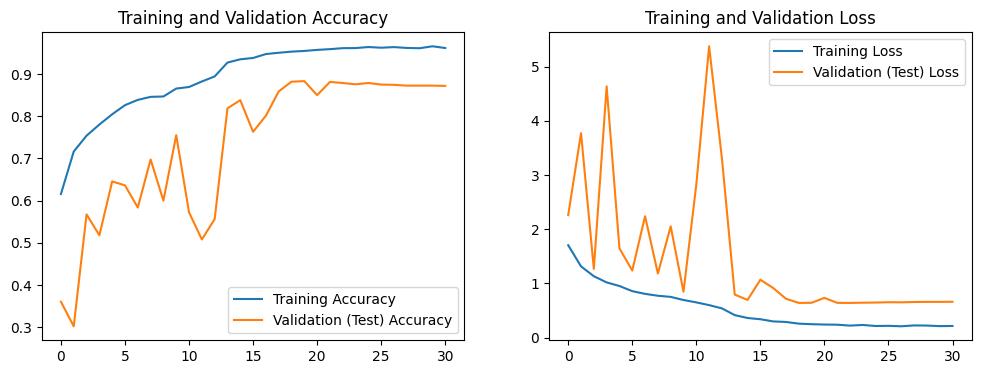

In [7]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
actual_epochs = len(history.history['accuracy'])
epochs_range = range(actual_epochs)

plt.figure(figsize=(12, 4))

# Gráfica de Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation (Test) Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Gráfica de Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation (Test) Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


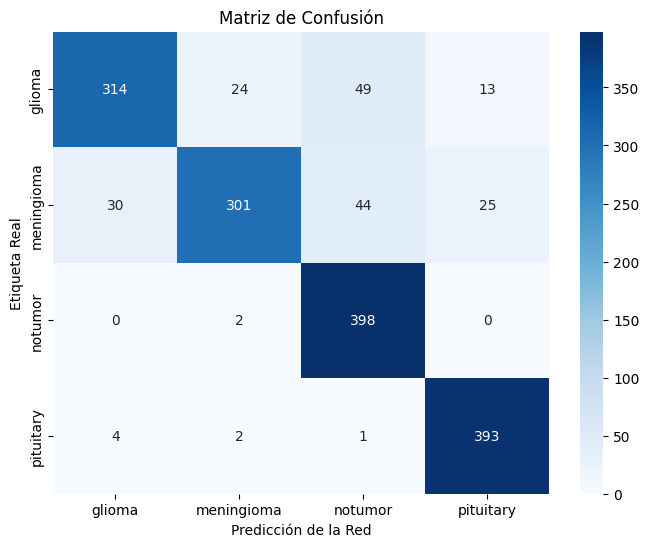

              precision    recall  f1-score   support

      glioma       0.90      0.79      0.84       400
  meningioma       0.91      0.75      0.83       400
     notumor       0.81      0.99      0.89       400
   pituitary       0.91      0.98      0.95       400

    accuracy                           0.88      1600
   macro avg       0.88      0.88      0.88      1600
weighted avg       0.88      0.88      0.88      1600

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step


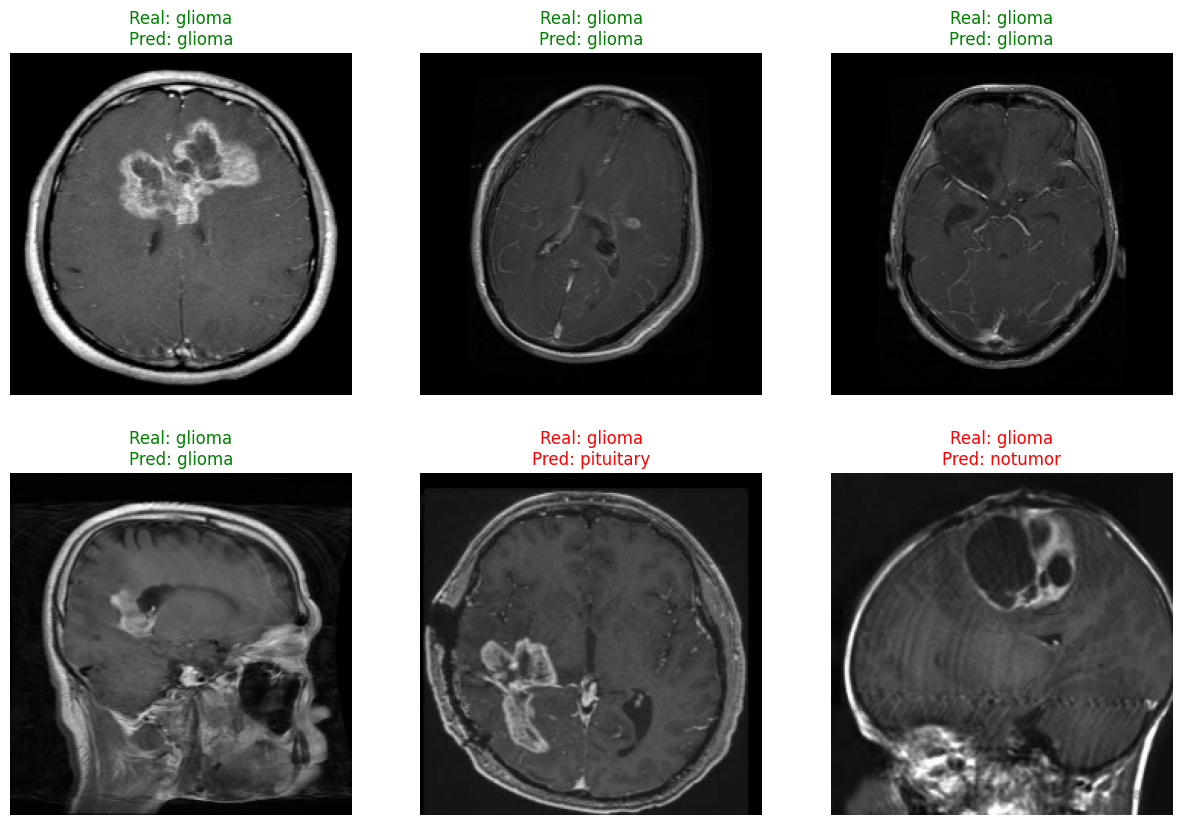

In [8]:
# Obtener las etiquetas reales del dataset de prueba
y_true = np.concatenate([y for x, y in test_dataset], axis=0)

# Hacer predicciones con el modelo
predictions = model.predict(test_dataset)
y_pred = np.argmax(predictions, axis=1)

# Crear la matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Graficar la matriz con Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción de la Red')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(classification_report(y_true, y_pred, target_names=class_names))

# Tomar un solo lote de imágenes y etiquetas del test_dataset
for images, labels in test_dataset.take(1):
    # Predecir sobre este lote
    batch_predictions = model.predict(images)
    batch_pred_labels = np.argmax(batch_predictions, axis=1)
    
    plt.figure(figsize=(15, 10))
    # Mostrar las primeras 6 imágenes del lote
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        
        # Convertir imagen a formato visualizable
        img = images[i].numpy().astype("uint8")
        plt.imshow(img)
        
        real_label = class_names[labels[i]]
        pred_label = class_names[batch_pred_labels[i]]
        
        # Si la predicción es correcta, título en verde. Si falla, en rojo.
        color = "green" if real_label == pred_label else "red"
        
        plt.title(f"Real: {real_label}\nPred: {pred_label}", color=color)
        plt.axis("off")
        
    plt.show()
    break 

In [9]:
# Guardar el modelo en formato nativo de Keras (.keras)
model.save('modelo_tumores_cerebrales.keras')